# Modular Solar-Powered Spray Cooling Canopies
## Climate-based performance evaluation
**Corrections applied relative to original:**
1. Single authoritative `cluster_names` dict used across all figures
2. Column name bug fixed: `summer_water_use_L_per_module` (was `_per_m2pv_per_module`)
3. SAPM coefficients updated to glass/polymer open-rack (a=−3.56, b=−0.075), consistent with Section 2.3.1
4. Duty cycle ramp corrected to 0.25→1.0 range, consistent with Section 2.3.2
5. Elbow + silhouette plots added to justify k=6
6. All figures use shared colour palette keyed by archetype name
7. 1:1 reference line (autonomy=1) added to Figure 3
8. Reference slope line (54 L/h) added to Figure 5


In [ ]:
# ============================================================
# Modular Solar-Powered Spray Cooling Canopies
# Climate-based performance evaluation from EPW (TMYx 2009-2023)
# ============================================================
# Outputs:
#   results_by_city.csv              – per-location metrics
#   results_by_cluster.csv           – archetype-level summary
#   fig2_Ta_vs_RH_archetypes.png     – climate scatter
#   fig3_PV_vs_Load.png              – energy balance
#   fig4_autonomy_by_archetype.png   – autonomy box plot
#   fig5_water_vs_mist_hours.png     – water scaling
#   fig_elbow_silhouette.png         – k-selection justification


In [1]:
!pip -q install pvlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 28.9 MB/s eta 0:00:00


In [2]:
# ============================================================

# ---- 0) Dependencies ----
# !pip -q install pvlib scikit-learn tqdm

# ============================================================

import os, re, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

import pvlib


In [3]:
# ============================================================
# 1) Google Drive (Colab only)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# ============================================================
# 2) USER SETTINGS
# ============================================================

ROOT_DIR = "/content/drive/MyDrive/Datasets/Climate_Files/Turkey"
OUT_DIR  = "/content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs"
os.makedirs(OUT_DIR, exist_ok=True)

SUMMER_MONTHS = [6, 7, 8]
SUMMER_HOURS  = (10, 18)   # 10:00 – 17:59 (< 18)

# ---- PV assumptions ----
PV_AREA_M2   = 1.0          # normalized; scale results linearly with real area
PV_EFF_STC   = 0.20         # crystalline Si, typical 18–22%
PV_GAMMA_PDC = -0.004       # power temp coefficient [1/°C]
TILT_MODE    = "latitude"   # "latitude" or use FIXED_TILT_DEG
FIXED_TILT_DEG = 30
AZIMUTH_DEG  = 180          # south-facing

# ---- SAPM cell-temperature coefficients ----
# Open-rack glass/polymer (consistent with Section 2.3.1)
SAPM_A      = -3.56
SAPM_B      = -0.075
SAPM_DELTA_T = 3

# ---- Electrical loads ----
PUMP_POWER_W     = 250   # W when misting ON
CONTROLS_POWER_W =   8   # W when misting ON
STANDBY_POWER_W  =   2   # W when misting OFF
BATTERY_KWH      = 1.0   # usable kWh per module

# ---- Misting / water ----
WATER_FLOW_LPM = 2.0    # L/min per module at full duty

# ---- Adaptive control thresholds (Section 2.3.2) ----
T_SET    = 32.0   # °C – temperature activation threshold (UTCI moderate stress)
RH_MAX   = 65.0   # %  – humidity deactivation threshold
G_MIN    = 200.0  # W/m² – minimum POA irradiance
T_RAMP   =  8.0   # °C – temperature range over which duty ramps 0.25 → 1.0

# ---- Clustering ----
K_CLUSTERS = 6


In [5]:
# ============================================================
# 3) Helper functions
# ============================================================

def find_epw(root):
    files = sorted(glob.glob(os.path.join(root, "**", "*.epw"), recursive=True))
    if not files:
        raise FileNotFoundError(f"No EPW files found under '{root}'.")
    return files


def city_name(epw_path):
    name = Path(epw_path).name
    m = re.match(r"^[A-Z]{3}_[A-Z]{2}_(.+?)\.\d+_", name)
    return m.group(1) if m else name.split(".")[0]


def summer_filter(df):
    df2 = df[df.index.month.isin(SUMMER_MONTHS)]
    h0, h1 = SUMMER_HOURS
    return df2[(df2.index.hour >= h0) & (df2.index.hour < h1)].copy()


def duty_cycle(Ta, RH, GHI):
    """
    Rule-based duty cycle, Section 2.3.2.
    ON only when Ta >= T_SET, RH <= RH_MAX, GHI >= G_MIN.
    Duty ramps linearly from 0.25 to 1.0 as Ta rises from T_SET to T_SET+T_RAMP.
    Duty is reduced linearly toward 0.25 as RH approaches RH_MAX.
    Combined formula preserves the 0.25 minimum when active.
    """
    cond = (Ta >= T_SET) & (RH <= RH_MAX) & (GHI >= G_MIN)
    duty = np.zeros_like(Ta, dtype=float)

    temp_factor = np.clip((Ta - T_SET) / T_RAMP, 0.0, 1.0)          # 0 → 1
    hum_factor  = np.clip((RH_MAX - RH) / RH_MAX, 0.0, 1.0)          # 1 at low RH → 0 at RH_MAX

    # duty: 0.25 at activation edge, 1.0 at T_SET+T_RAMP and low RH
    raw = 0.25 + 0.75 * temp_factor * hum_factor
    duty[cond] = raw[cond]
    return duty


def pv_power(epw_df, meta):
    """PVWatts-type DC power (W) per PV_AREA_M2 using pvlib."""
    lat = meta["latitude"]
    lon = meta["longitude"]

    # Timezone
    tz_raw = meta.get("tz", meta.get("TZ", None))
    if isinstance(tz_raw, str) and not tz_raw.lstrip("-").isdigit():
        tzname = tz_raw
    elif tz_raw is not None:
        tzname = f"Etc/GMT{-int(float(tz_raw))}"
    else:
        tzname = "Etc/GMT-3"   # Turkey default UTC+3

    location = pvlib.location.Location(
        lat, lon, tz=tzname,
        altitude=float(meta.get("altitude", 0)),
        name=meta.get("city", "site")
    )

    times  = epw_df.index
    solpos = location.get_solarposition(times)

    tilt = abs(lat) if TILT_MODE == "latitude" else FIXED_TILT_DEG

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=tilt, surface_azimuth=AZIMUTH_DEG,
        solar_zenith=solpos["apparent_zenith"], solar_azimuth=solpos["azimuth"],
        dni=epw_df["dni"].astype(float),
        ghi=epw_df["ghi"].astype(float),
        dhi=epw_df["dhi"].astype(float),
        model="isotropic"          # matches Section 2.3.1 specification
    )
    G_poa = poa["poa_global"].fillna(0.0)

    # SAPM cell temperature (Section 2.3.1: glass/polymer, open-rack)
    T_cell = pvlib.temperature.sapm_cell(
        G_poa,
        epw_df["temp_air"].astype(float),
        epw_df["wind_speed"].astype(float),
        a=SAPM_A, b=SAPM_B, deltaT=SAPM_DELTA_T
    )

    # PVWatts DC model
    Pdc0_kw = PV_AREA_M2 * PV_EFF_STC * 1.0   # kW at STC (1000 W/m²)
    pdc_kw  = pvlib.pvsystem.pvwatts_dc(
        g_poa_effective=G_poa,
        temp_cell=T_cell,
        pdc0=Pdc0_kw,
        gamma_pdc=PV_GAMMA_PDC
    )
    return pd.DataFrame({
        "poa_global_wm2": G_poa,
        "temp_cell_c":    T_cell,
        "pdc_w":          (pdc_kw * 1000.0).clip(lower=0.0)
    }, index=times)


In [6]:
# ============================================================
# 4) Main loop
# ============================================================

epw_files = find_epw(ROOT_DIR)
print(f"Found {len(epw_files)} EPW files.")

records = []

for epw_path in tqdm(epw_files, desc="Processing EPW"):
    city = city_name(epw_path)
    epw_df, meta = pvlib.iotools.read_epw(epw_path)

    # Include precipitation for clustering robustness / reviewer response.
    # pvlib EPW column is usually "precipitable_water" and/or "liquid_precipitation_depth".
    # For actual rainfall amount, use "liquid_precipitation_depth" if available.
    needed = ["temp_air", "relative_humidity", "wind_speed", "ghi", "dni", "dhi"]
    precip_col = None
    for candidate in ["liquid_precipitation_depth", "precipitable_water"]:
        if candidate in epw_df.columns:
            precip_col = candidate
            break

    missing = [c for c in needed if c not in epw_df.columns]
    if missing:
        print(f"[WARN] {city}: missing {missing} – skipped.")
        continue

    use_cols = needed.copy()
    if precip_col is not None:
        use_cols.append(precip_col)

    df_s = summer_filter(epw_df[use_cols])

    pv_all = pv_power(epw_df[needed], meta)
    pv_s   = pv_all.loc[df_s.index]

    Ta  = df_s["temp_air"].values
    RH  = df_s["relative_humidity"].values
    GHI = df_s["ghi"].values

    duty = duty_cycle(Ta, RH, GHI)

    dt = 1.0  # hourly time step

    pump_wh = float(np.sum(PUMP_POWER_W * duty * dt))
    controls_wh = float(
        np.sum(np.where(duty > 0, CONTROLS_POWER_W, STANDBY_POWER_W) * dt)
    )
    pv_wh = float(np.sum(pv_s["pdc_w"].values * dt))

    water_L = float(np.sum(WATER_FLOW_LPM * 60.0 * duty * dt))

    load_wh = pump_wh + controls_wh
    autonomy = pv_wh / load_wh if load_wh > 0 else np.nan
    mist_hours = float(np.sum(duty > 0))
    batt_hrs_full = (BATTERY_KWH * 1000.0) / PUMP_POWER_W

    # Summer precipitation:
    # If "liquid_precipitation_depth" exists, use the summer sum.
    # If only "precipitable_water" exists, do NOT interpret it as rainfall;
    # keep it as an atmospheric water-column proxy.
    if precip_col is None:
        summer_precip_metric = np.nan
        summer_precip_note = "not_available"
    elif precip_col == "liquid_precipitation_depth":
        summer_precip_metric = float(df_s[precip_col].fillna(0.0).sum())
        summer_precip_note = "summer_sum_liquid_precipitation_depth"
    else:
        summer_precip_metric = float(df_s[precip_col].astype(float).mean())
        summer_precip_note = "summer_mean_precipitable_water"

    records.append({
        "city": city,
        "epw_file": Path(epw_path).name,
        "latitude": meta.get("latitude", np.nan),
        "longitude": meta.get("longitude", np.nan),
        "altitude_m": meta.get("altitude", np.nan),

        "summer_mean_Ta_C": float(np.mean(Ta)) if len(Ta) else np.nan,
        "summer_p95_Ta_C": float(np.percentile(Ta, 95)) if len(Ta) else np.nan,
        "summer_mean_RH_pct": float(np.mean(RH)) if len(RH) else np.nan,
        "summer_mean_wind_ms": float(np.mean(df_s["wind_speed"].values)) if len(df_s) else np.nan,
        "summer_mean_GHI_Wm2": float(np.mean(GHI)) if len(GHI) else np.nan,

        # New precipitation metric for clustering robustness
        "summer_precip_metric": summer_precip_metric,
        "summer_precip_metric_type": summer_precip_note,

        "summer_mist_hours_h": mist_hours,
        "summer_water_use_L_per_module": water_L,

        "summer_pv_energy_Wh_per_m2pv": pv_wh,
        "summer_load_energy_Wh_per_module": load_wh,
        "summer_autonomy_ratio": autonomy,

        "battery_usable_kWh": BATTERY_KWH,
        "battery_full_pump_hours_h": batt_hrs_full,
    })

results = pd.DataFrame.from_records(records).sort_values("city").reset_index(drop=True)

print("\nSample output:")
print(
    results[
        [
            "city",
            "summer_mean_Ta_C",
            "summer_mean_RH_pct",
            "summer_precip_metric",
            "summer_mist_hours_h",
            "summer_water_use_L_per_module",
            "summer_autonomy_ratio",
        ]
    ].head(8).to_string(index=False)
)

print("\nPrecipitation metric type counts:")
print(results["summer_precip_metric_type"].value_counts(dropna=False).to_string())

results.to_csv(os.path.join(OUT_DIR, "results_by_city.csv"), index=False)

Found 110 EPW files.


Processing EPW:   0%|          | 0/110 [00:00<?, ?it/s]/tmp/ipykernel_3270/388335231.py:89: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  pdc_kw  = pvlib.pvsystem.pvwatts_dc(
Processing EPW:   1%|          | 1/110 [00:00<01:32,  1.18it/s]/tmp/ipykernel_3270/388335231.py:89: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  pdc_kw  = pvlib.pvsystem.pvwatts_dc(
Processing EPW:   2%|▏         | 2/110 [00:01<01:15,  1.44it/s]/tmp/ipykernel_3270/388335231.py:89: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  pdc_kw  = pvlib.pvsystem.pvwatts_dc(
Processing EPW:   3%|▎         | 3/110 [00:02<01:11,  1.51it/s]/tmp/ipykernel_3270/388335231.py:89: pvlibDeprecationWarning: Paramet


Sample output:
              city  summer_mean_Ta_C  summer_mean_RH_pct  summer_precip_metric  summer_mist_hours_h  summer_water_use_L_per_module  summer_autonomy_ratio
 Adana-Incirlik.AB         32.875543           47.127717                  15.7                529.0                   19799.053846               1.906387
         Adapazari         28.195788           57.976902                  89.7                 91.0                    3592.771154               8.829987
          Adiyaman         35.053804           20.883152                   6.1                579.0                   38733.507692               1.062644
              Agri         26.819022           38.061141                  86.9                 68.0                    2354.238462              13.153234
           Aksaray         28.130299           26.479620                  16.5                101.0                    4752.392308               7.882001
           Aksehir         27.308152           33.869565    

In [7]:
# ============================================================
# 5) K-means clustering: validation and robustness checks
# ============================================================

# ---- Primary clustering feature set ----
# Reviewer note:
# These variables represent summer heat stress, humidity limitation,
# solar resource, and wind-driven dispersion/evaporation context.
feature_cols_primary = [
    "summer_mean_Ta_C",
    "summer_p95_Ta_C",
    "summer_mean_RH_pct",
    "summer_mean_wind_ms",
    "summer_mean_GHI_Wm2",
]

# ---- Extended feature set including precipitation/water-availability proxy ----
# Use only if available. This responds to the reviewer request to include precipitation.
feature_cols_extended = feature_cols_primary.copy()
if "summer_precip_metric" in results.columns and results["summer_precip_metric"].notna().sum() > 0:
    feature_cols_extended.append("summer_precip_metric")

# Choose whether to use precipitation in the MAIN clustering.
# Recommended reviewer-safe setting:
#   True  = primary clustering includes precipitation if available.
#   False = primary clustering remains climate-performance based; precipitation used as robustness check.
USE_PRECIP_IN_MAIN_CLUSTERING = True

if USE_PRECIP_IN_MAIN_CLUSTERING and len(feature_cols_extended) > len(feature_cols_primary):
    feature_cols = feature_cols_extended
    print("Main clustering uses precipitation-inclusive feature set:")
else:
    feature_cols = feature_cols_primary
    print("Main clustering uses original five-variable feature set:")

print(feature_cols)

df_feat = results.dropna(subset=feature_cols).copy()

X = df_feat[feature_cols].values
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# ---- Validation metrics for k = 2...10 ----
ks = list(range(2, 11))
validation_records = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=100, random_state=42)
    labels = km.fit_predict(Xz)

    validation_records.append({
        "k": k,
        "wcss_inertia": km.inertia_,
        "silhouette": silhouette_score(Xz, labels),
        "calinski_harabasz": calinski_harabasz_score(Xz, labels),
        "davies_bouldin": davies_bouldin_score(Xz, labels),
    })

cluster_validation = pd.DataFrame(validation_records)
cluster_validation.to_csv(os.path.join(OUT_DIR, "cluster_validation_metrics.csv"), index=False)

print("\nCluster validation metrics:")
print(cluster_validation.to_string(index=False))

# ---- Figure: WCSS, silhouette, CH, DB ----
fig_val, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(cluster_validation["k"], cluster_validation["wcss_inertia"], "o-", color="steelblue")
axes[0, 0].axvline(K_CLUSTERS, color="red", linestyle="--", alpha=0.6)
axes[0, 0].set_title("Elbow criterion")
axes[0, 0].set_xlabel("Number of clusters, k")
axes[0, 0].set_ylabel("WCSS / inertia")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(cluster_validation["k"], cluster_validation["silhouette"], "o-", color="darkorange")
axes[0, 1].axvline(K_CLUSTERS, color="red", linestyle="--", alpha=0.6)
axes[0, 1].set_title("Silhouette coefficient")
axes[0, 1].set_xlabel("Number of clusters, k")
axes[0, 1].set_ylabel("Silhouette")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(cluster_validation["k"], cluster_validation["calinski_harabasz"], "o-", color="seagreen")
axes[1, 0].axvline(K_CLUSTERS, color="red", linestyle="--", alpha=0.6)
axes[1, 0].set_title("Calinski–Harabasz index")
axes[1, 0].set_xlabel("Number of clusters, k")
axes[1, 0].set_ylabel("CH index")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(cluster_validation["k"], cluster_validation["davies_bouldin"], "o-", color="purple")
axes[1, 1].axvline(K_CLUSTERS, color="red", linestyle="--", alpha=0.6)
axes[1, 1].set_title("Davies–Bouldin index")
axes[1, 1].set_xlabel("Number of clusters, k")
axes[1, 1].set_ylabel("DB index (lower is better)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig_cluster_validation_metrics.png"), dpi=300, bbox_inches="tight")
plt.close()

print("Saved: fig_cluster_validation_metrics.png")

# ---- Compare k = 4, 5, 6 interpretability ----
comparison_rows = []

for k in [4, 5, 6]:
    km = KMeans(n_clusters=k, n_init=100, random_state=42)
    labels = km.fit_predict(Xz)

    temp_df = df_feat.copy()
    temp_df[f"k{k}_cluster"] = labels

    summary = (
        temp_df.groupby(f"k{k}_cluster")
        .agg(
            n=("city", "count"),
            mean_Ta_C=("summer_mean_Ta_C", "mean"),
            p95_Ta_C=("summer_p95_Ta_C", "mean"),
            mean_RH_pct=("summer_mean_RH_pct", "mean"),
            mean_wind_ms=("summer_mean_wind_ms", "mean"),
            mean_GHI_Wm2=("summer_mean_GHI_Wm2", "mean"),
            mean_precip=("summer_precip_metric", "mean") if "summer_precip_metric" in temp_df.columns else ("summer_mean_GHI_Wm2", "mean"),
            mean_mist_hours=("summer_mist_hours_h", "mean"),
            mean_water_L=("summer_water_use_L_per_module", "mean"),
            mean_autonomy=("summer_autonomy_ratio", "mean"),
        )
        .reset_index()
    )
    summary.insert(0, "k", k)
    comparison_rows.append(summary)

k456_summary = pd.concat(comparison_rows, ignore_index=True)
k456_summary.to_csv(os.path.join(OUT_DIR, "cluster_k4_k5_k6_summary.csv"), index=False)

print("\nInterpretability comparison for k = 4, 5, 6:")
print(k456_summary.to_string(index=False))

# ---- Fit final k-means model ----
kmeans = KMeans(n_clusters=K_CLUSTERS, n_init=100, random_state=42)
df_feat["cluster"] = kmeans.fit_predict(Xz)

# Merge back
results = results.drop(columns=["cluster", "archetype"], errors="ignore")
results = results.merge(df_feat[["city", "cluster"]], on="city", how="left")

# ---- Verify cluster statistics before naming ----
cl_check = (
    results.groupby("cluster")
    .agg(
        n=("city", "count"),
        mean_Ta_C=("summer_mean_Ta_C", "mean"),
        p95_Ta_C=("summer_p95_Ta_C", "mean"),
        mean_RH_pct=("summer_mean_RH_pct", "mean"),
        mean_wind_ms=("summer_mean_wind_ms", "mean"),
        mean_GHI_Wm2=("summer_mean_GHI_Wm2", "mean"),
        mean_precip=("summer_precip_metric", "mean") if "summer_precip_metric" in results.columns else ("summer_mean_GHI_Wm2", "mean"),
        mean_mist_hours=("summer_mist_hours_h", "mean"),
        mean_water_L=("summer_water_use_L_per_module", "mean"),
        mean_autonomy=("summer_autonomy_ratio", "mean"),
    )
    .reset_index()
    .sort_values("mean_Ta_C", ascending=False)
)

print("\nFinal cluster verification table:")
print(cl_check.to_string(index=False))
cl_check.to_csv(os.path.join(OUT_DIR, "final_cluster_verification.csv"), index=False)

# ============================================================
# IMPORTANT:
# After running this cell, inspect "Final cluster verification table".
# If cluster indices changed because precipitation was included, update
# cluster_names below according to the printed statistics.
# ============================================================

cluster_names = {
    0: "Semi-Arid Plateau",
    1: "Humid Black Sea",
    2: "Temperate Humid Transitional",
    3: "Hot–Dry Inland",
    4: "Humid Mediterranean Coastal",
    5: "Temperate / Windy Coastal",
}

results["archetype"] = results["cluster"].map(cluster_names).fillna("Unknown")

# ---- Robustness check 1: precipitation vs no-precipitation clustering ----
robustness_records = []

if len(feature_cols_extended) > len(feature_cols_primary):
    # Original five-variable clustering
    X_primary = StandardScaler().fit_transform(results.dropna(subset=feature_cols_primary)[feature_cols_primary].values)
    km_primary = KMeans(n_clusters=K_CLUSTERS, n_init=100, random_state=42)
    labels_primary = km_primary.fit_predict(X_primary)

    # Extended precipitation-inclusive clustering
    common_df = results.dropna(subset=feature_cols_extended).copy()
    X_ext = StandardScaler().fit_transform(common_df[feature_cols_extended].values)
    km_ext = KMeans(n_clusters=K_CLUSTERS, n_init=100, random_state=42)
    labels_ext = km_ext.fit_predict(X_ext)

    # Note: ARI is label-invariant, so no need to align cluster IDs.
    ari_precip = adjusted_rand_score(
        labels_primary[:len(labels_ext)],
        labels_ext
    )

    robustness_records.append({
        "comparison": "KMeans primary features vs precipitation-inclusive features",
        "adjusted_rand_index": ari_precip,
    })

# ---- Robustness check 2: k-means vs hierarchical Ward clustering ----
ward = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage="ward")
ward_labels = ward.fit_predict(Xz)

ari_ward = adjusted_rand_score(df_feat["cluster"].values, ward_labels)
robustness_records.append({
    "comparison": "KMeans vs Ward hierarchical clustering",
    "adjusted_rand_index": ari_ward,
})

cluster_robustness = pd.DataFrame(robustness_records)
cluster_robustness.to_csv(os.path.join(OUT_DIR, "cluster_robustness_checks.csv"), index=False)

print("\nCluster robustness checks:")
print(cluster_robustness.to_string(index=False))

# ---- Cluster summary for manuscript ----
cluster_summary = (
    results.groupby("archetype", dropna=False)
    .agg(
        n_cities=("city", "count"),
        mean_Ta_C=("summer_mean_Ta_C", "mean"),
        mean_RH_pct=("summer_mean_RH_pct", "mean"),
        mean_GHI_Wm2=("summer_mean_GHI_Wm2", "mean"),
        mean_precip_metric=("summer_precip_metric", "mean") if "summer_precip_metric" in results.columns else ("summer_mean_GHI_Wm2", "mean"),
        mean_autonomy=("summer_autonomy_ratio", "mean"),
        mean_water_L=("summer_water_use_L_per_module", "mean"),
        mean_mist_hours_h=("summer_mist_hours_h", "mean"),
    )
    .reset_index()
)

print("\nCluster summary:")
print(cluster_summary.to_string(index=False))

cluster_summary.to_csv(os.path.join(OUT_DIR, "results_by_cluster.csv"), index=False)
results.to_csv(os.path.join(OUT_DIR, "results_by_city_with_clusters.csv"), index=False)

print("\nSaved:")
print(" - cluster_validation_metrics.csv")
print(" - fig_cluster_validation_metrics.png")
print(" - cluster_k4_k5_k6_summary.csv")
print(" - final_cluster_verification.csv")
print(" - cluster_robustness_checks.csv")
print(" - results_by_cluster.csv")
print(" - results_by_city_with_clusters.csv")

Main clustering uses precipitation-inclusive feature set:
['summer_mean_Ta_C', 'summer_p95_Ta_C', 'summer_mean_RH_pct', 'summer_mean_wind_ms', 'summer_mean_GHI_Wm2', 'summer_precip_metric']

Cluster validation metrics:
 k  wcss_inertia  silhouette  calinski_harabasz  davies_bouldin
 2    424.073061    0.288433          60.084244        1.238773
 3    324.482706    0.264591          55.319359        1.189595
 4    265.249867    0.277818          52.583770        1.190403
 5    227.948193    0.263871          49.754112        1.152702
 6    201.022107    0.279884          47.490996        1.151045
 7    181.433727    0.274792          45.280378        1.112144
 8    163.590182    0.257691          44.216591        1.143241
 9    148.270446    0.253029          43.572983        1.109789
10    137.174522    0.249391          42.348768        1.121714
Saved: fig_cluster_validation_metrics.png

Interpretability comparison for k = 4, 5, 6:
 k  k4_cluster  n  mean_Ta_C  p95_Ta_C  mean_RH_pct  

In [9]:
# ============================================================
# 6) Figures
# ============================================================

# Shared color palette – one color per archetype (consistent across all figures)
PALETTE = {
    "Hot–Dry Inland": "#F44336",
    "Humid Black Sea": "#4CAF50",
    "Humid Mediterranean Coastal": "#00BCD4",
    "Semi-Arid Plateau": "#FF9800",
    "Temperate / Windy Coastal": "#2196F3",
    "Temperate Humid Transitional": "#9C27B0",
}

def archetype_color(name):
    return PALETTE.get(name, "gray")

# ── Figure 2: Ta vs RH scatter ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8.5, 5.2))
for name in cluster_names.values():
    sub = results[results["archetype"] == name]
    ax2.scatter(
        sub["summer_mean_Ta_C"], sub["summer_mean_RH_pct"],
        s=40, alpha=0.85, color=archetype_color(name),
        edgecolors="white", linewidths=0.4, label=name, zorder=3
    )
ax2.axhline(RH_MAX, color="black", linestyle="--", linewidth=0.8,
            alpha=0.5, label=f"RH_max = {RH_MAX}%")
ax2.set_xlabel("Summer mean air temperature, Ta (\u00b0C)")
ax2.set_ylabel("Summer mean relative humidity, RH (%)")
ax2.set_title("Turkey EPW locations: summer climate archetypes")
ax2.legend(loc="upper right", fontsize=8.5, frameon=False)
ax2.grid(True, linewidth=0.4, alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig2_Ta_vs_RH_archetypes.png"), dpi=300, bbox_inches="tight")
plt.close()
print("Saved: fig2_Ta_vs_RH_archetypes.png")

# ── Figure 3: PV energy vs load ───────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7.5, 5.0))
for name in cluster_names.values():
    sub = results[results["archetype"] == name]
    ax3.scatter(
        sub["summer_pv_energy_Wh_per_m2pv"] / 1000,
        sub["summer_load_energy_Wh_per_module"] / 1000,
        s=40, alpha=0.85, color=archetype_color(name),
        edgecolors="white", linewidths=0.4, label=name, zorder=3
    )
# 1:1 reference line (autonomy = 1)
lims = [0, results["summer_pv_energy_Wh_per_m2pv"].max() / 1000 * 1.05]
ax3.plot(lims, lims, "k--", linewidth=0.9, alpha=0.5, label="Autonomy = 1")
ax3.set_xlabel("Summer PV energy (kWh per m\u00b2 PV)")
ax3.set_ylabel("Summer electrical load (kWh per module)")
ax3.set_title("Energy balance across 110 locations (summer daytime)")
ax3.legend(fontsize=8.5, frameon=False)
ax3.grid(True, linewidth=0.4, alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig3_PV_vs_Load.png"), dpi=300, bbox_inches="tight")
plt.close()
print("Saved: fig3_PV_vs_Load.png")

# ── Figure 4: Autonomy box plot ───────────────────────────────────────────────
# Order archetypes by median autonomy (ascending) for readability
order = (
    results.groupby("archetype")["summer_autonomy_ratio"]
    .median().sort_values().index.tolist()
)
box_data   = [results.loc[results["archetype"]==a, "summer_autonomy_ratio"].dropna().values for a in order]
box_colors = [archetype_color(a) for a in order]

fig4, ax4 = plt.subplots(figsize=(9.0, 5.0))
bp = ax4.boxplot(box_data, vert=False, patch_artist=True,
                 showfliers=False, widths=0.55)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set(facecolor=color, alpha=0.75, edgecolor="black", linewidth=1.1)
for median in bp["medians"]:
    median.set(color="black", linewidth=1.8)
for w in bp["whiskers"]:  w.set(color="black", linewidth=1.0)
for c in bp["caps"]:      c.set(color="black", linewidth=1.0)

ax4.set_yticklabels(order, fontsize=10)
ax4.set_xlabel("PV-to-load autonomy ratio (\u2013)", fontsize=11)
ax4.set_title("Energy autonomy by climate archetype (summer daytime)", fontsize=11)
ax4.axvline(1.0, color="red", linestyle="--", linewidth=0.9, alpha=0.6, label="Autonomy = 1")
ax4.legend(fontsize=9, frameon=False)
ax4.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig4_autonomy_by_archetype.png"), dpi=300, bbox_inches="tight")
plt.close()
print("Saved: fig4_autonomy_by_archetype.png")

# ── Figure 5: Water use vs misting hours ─────────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(7.5, 5.0))
for name in cluster_names.values():
    sub = results[results["archetype"] == name]
    ax5.scatter(
        sub["summer_mist_hours_h"],
        sub["summer_water_use_L_per_module"],
        s=40, alpha=0.85, color=archetype_color(name),
        edgecolors="white", linewidths=0.4, label=name, zorder=3
    )
# Reference slope: 54 L/h at mean duty ~0.45
h_ref = np.linspace(0, results["summer_mist_hours_h"].max() * 1.05, 100)
ax5.plot(h_ref, h_ref * 54, "k--", linewidth=0.9, alpha=0.5,
         label="Reference slope: 54 L/h")
ax5.set_xlabel("Feasible misting hours (h), summer daytime")
ax5.set_ylabel("Water consumption (L per module)")
ax5.set_title("Water demand scaling with misting opportunity")
ax5.legend(fontsize=8.5, frameon=False)
ax5.grid(True, linewidth=0.4, alpha=0.35)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig5_water_vs_mist_hours.png"), dpi=300, bbox_inches="tight")
plt.close()
print("Saved: fig5_water_vs_mist_hours.png")

print(f"\nAll outputs saved to: {OUT_DIR}")


Saved: fig2_Ta_vs_RH_archetypes.png
Saved: fig3_PV_vs_Load.png
Saved: fig4_autonomy_by_archetype.png
Saved: fig5_water_vs_mist_hours.png

All outputs saved to: /content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs


Detected baseline parameters:
T_SET_BASE       = 32.0
RH_MAX_BASE      = 65.0
G_MIN_BASE       = 200.0
T_RAMP_BASE      = 8.0
WATER_FLOW_BASE  = 2.0
PUMP_POWER_BASE  = 250
PV_AREA_BASE     = 1.0
CONTROLS_POWER   = 8
STANDBY_POWER    = 2


Sensitivity analysis over EPW files:   0%|          | 0/110 [00:00<?, ?it/s]/tmp/ipykernel_3270/388335231.py:89: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  pdc_kw  = pvlib.pvsystem.pvwatts_dc(
Sensitivity analysis over EPW files:   1%|          | 1/110 [00:00<01:08,  1.59it/s]/tmp/ipykernel_3270/388335231.py:89: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  pdc_kw  = pvlib.pvsystem.pvwatts_dc(
Sensitivity analysis over EPW files:   2%|▏         | 2/110 [00:01<01:03,  1.71it/s]/tmp/ipykernel_3270/388335231.py:89: pvlibDeprecationWarning: Parameter 'g_poa_effective' has been renamed since 0.13.0. and will be removed soon. Please use 'effective_irradiance' instead.
  pdc_kw  = pvlib.pvsystem.pvwatts_dc(
Sensitivity analysis over EPW files:   3%|▎         | 3/110 [00:01<01


Baseline consistency check against main results:


,mean_misting_hours_h,mean_water_use_L_per_module,mean_autonomy_ratio,main_misting_hours_h,main_water_use_L_per_module,main_autonomy_ratio,diff_misting_h,diff_water_L,diff_autonomy
archetype,,,,,,,,,
Hot–Dry Inland,501.904762,30151.799451,1.547208,501.904762,30151.799451,1.547208,0.0,0.0,0.000000e+00
Humid Black Sea,11.428571,465.180495,39.675118,11.428571,465.180495,39.675118,0.0,0.0,0.000000e+00
Humid Mediterranean Coastal,186.000000,7120.340680,15.285728,186.000000,7120.340680,15.285728,0.0,0.0,-1.776357e-15
Semi-Arid Plateau,117.212121,5047.152448,11.607983,117.212121,5047.152448,11.607983,0.0,0.0,1.776357e-15
Temperate / Windy Coastal,157.769231,5927.808284,19.890712,157.769231,5927.808284,19.890712,0.0,0.0,0.000000e+00
Temperate Humid Transitional,62.826087,2481.332860,25.493283,62.826087,2481.332860,25.493283,0.0,0.0,0.000000e+00



OK: Sensitivity baseline matches main results.


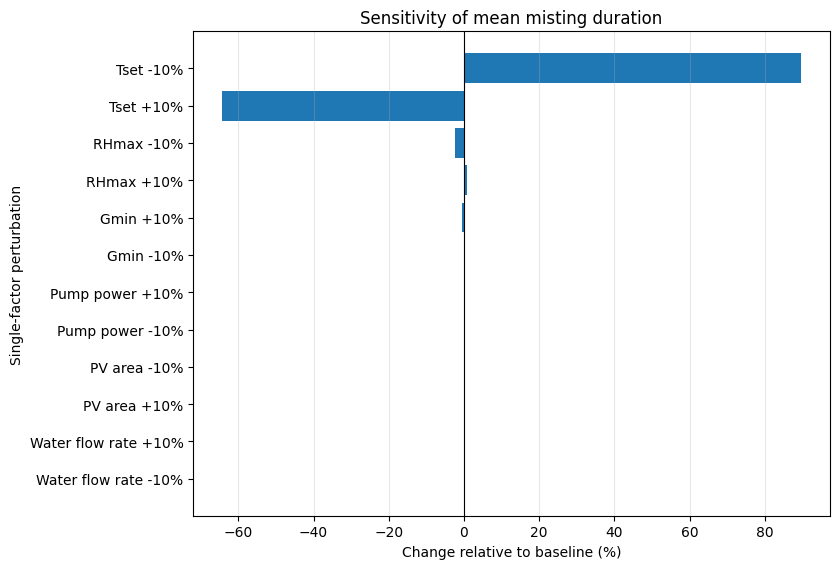

Saved: /content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/fig_sensitivity_tornado_misting_hours.png


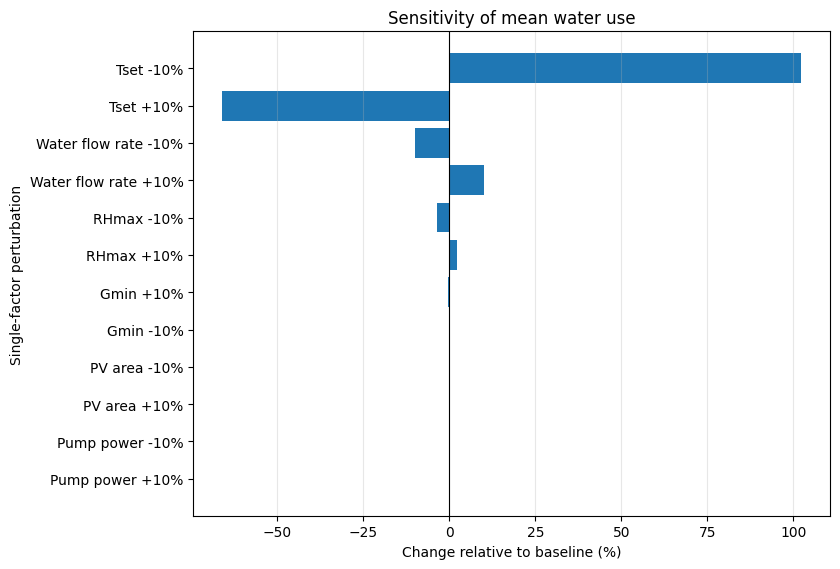

Saved: /content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/fig_sensitivity_tornado_water_use.png


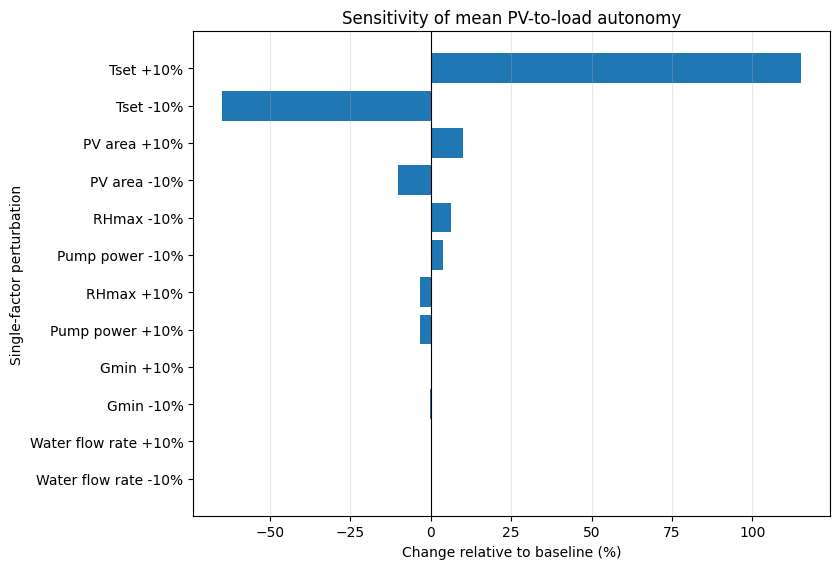

Saved: /content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/fig_sensitivity_tornado_autonomy.png

Saved sensitivity outputs:
/content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/sensitivity_by_city.csv
/content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/sensitivity_by_archetype.csv
/content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/sensitivity_overall.csv
/content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/pv_area_scaling_by_archetype.csv
/content/drive/MyDrive/Makaleler/Makale-Solar driven mist generation/corrected/Asfaw Beyene/MDPI-Climate/Revision 1/Outputs/sensitivity_baseline_check.csv

Overall sensitivity summary:


,scenario,parameter,direction,n_cities,mean_misting_hours_h,mean_water_use_L_per_module,mean_load_energy_Wh,mean_autonomy_ratio,pct_change_mean_misting_hours_h,pct_change_mean_water_use_L_per_module,pct_change_mean_load_energy_Wh,pct_change_mean_autonomy_ratio
0,Baseline,Baseline,baseline,110,185.472727,9360.878864,22086.667330,15.790181,0.000000,0.000000,0.000000,0.000000
1,Flow_minus10pct,Water flow rate,-10%,110,185.472727,8424.790977,22086.667330,15.790181,0.000000,-10.000000,0.000000,0.000000
2,Flow_plus10pct,Water flow rate,+10%,110,185.472727,10296.966750,22086.667330,15.790181,0.000000,10.000000,0.000000,0.000000
3,Gmin_minus10pct,Gmin,-10%,110,186.018182,9386.020647,22142.318772,15.772849,0.294089,0.268584,0.251968,-0.109762
4,Gmin_plus10pct,Gmin,+10%,110,184.518182,9318.625437,21992.912085,15.809037,-0.514655,-0.451383,-0.424488,0.119421
5,PVarea_2m2,PV area design,2 m²,110,185.472727,9360.878864,22086.667330,31.580361,0.000000,0.000000,0.000000,100.000000
6,PVarea_3m2,PV area design,3 m²,110,185.472727,9360.878864,22086.667330,47.370542,0.000000,0.000000,0.000000,200.000000
7,PVarea_minus10pct,PV area,-10%,110,185.472727,9360.878864,22086.667330,14.211163,0.000000,0.000000,0.000000,-10.000000
8,PVarea_plus10pct,PV area,+10%,110,185.472727,9360.878864,22086.667330,17.369199,0.000000,0.000000,0.000000,10.000000
9,Pump_minus10pct,Pump power,-10%,110,185.472727,9360.878864,20136.484233,16.374486,0.000000,0.000000,-8.829685,3.700432



PV area scaling by archetype:


,archetype,scenario,direction,mean_misting_hours_h,mean_water_use_L_per_module,mean_load_energy_Wh,mean_autonomy_ratio
0,Hot–Dry Inland,Baseline,baseline,501.904762,30151.799451,67299.677427,1.547208
5,Hot–Dry Inland,PVarea_2m2,2 m²,501.904762,30151.799451,67299.677427,3.094417
6,Hot–Dry Inland,PVarea_3m2,3 m²,501.904762,30151.799451,67299.677427,4.641625
15,Humid Black Sea,Baseline,baseline,11.428571,465.180495,2509.697459,39.675118
20,Humid Black Sea,PVarea_2m2,2 m²,11.428571,465.180495,2509.697459,79.350237
21,Humid Black Sea,PVarea_3m2,3 m²,11.428571,465.180495,2509.697459,119.025355
30,Humid Mediterranean Coastal,Baseline,baseline,186.000000,7120.340680,17422.043084,15.285728
35,Humid Mediterranean Coastal,PVarea_2m2,2 m²,186.000000,7120.340680,17422.043084,30.571457
36,Humid Mediterranean Coastal,PVarea_3m2,3 m²,186.000000,7120.340680,17422.043084,45.857185
45,Semi-Arid Plateau,Baseline,baseline,117.212121,5047.152448,12690.173660,11.607983


In [14]:
# ============================================================
# 7) Quantitative sensitivity analysis for reviewers
# Single-factor ±10% perturbation of key thresholds/system parameters
#
# IMPORTANT:
# This cell exactly matches the baseline model logic used in Cell 11:
# duty = 0.25 + 0.75 * temp_factor * hum_factor
#
# Outputs:
# - sensitivity_by_city.csv
# - sensitivity_by_archetype.csv
# - sensitivity_overall.csv
# - pv_area_scaling_by_archetype.csv
# - fig_sensitivity_tornado_misting_hours.png
# - fig_sensitivity_tornado_water_use.png
# - fig_sensitivity_tornado_autonomy.png
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# 7.1 Baseline parameters: match main notebook variable names
# ============================================================

T_SET_BASE = globals().get("T_SET", 32.0)
RH_MAX_BASE = globals().get("RH_MAX", 65.0)
G_MIN_BASE = globals().get("G_MIN", 200.0)
T_RAMP_BASE = globals().get("T_RAMP", 8.0)

WATER_FLOW_BASE = globals().get("WATER_FLOW_LPM", 2.0)
PUMP_POWER_BASE = globals().get("PUMP_POWER_W", 250.0)
PV_AREA_BASE = globals().get("PV_AREA_M2", 1.0)

CONTROLS_POWER_BASE = globals().get("CONTROLS_POWER_W", 8.0)
STANDBY_POWER_BASE = globals().get("STANDBY_POWER_W", 2.0)

print("Detected baseline parameters:")
print(f"T_SET_BASE       = {T_SET_BASE}")
print(f"RH_MAX_BASE      = {RH_MAX_BASE}")
print(f"G_MIN_BASE       = {G_MIN_BASE}")
print(f"T_RAMP_BASE      = {T_RAMP_BASE}")
print(f"WATER_FLOW_BASE  = {WATER_FLOW_BASE}")
print(f"PUMP_POWER_BASE  = {PUMP_POWER_BASE}")
print(f"PV_AREA_BASE     = {PV_AREA_BASE}")
print(f"CONTROLS_POWER   = {CONTROLS_POWER_BASE}")
print(f"STANDBY_POWER    = {STANDBY_POWER_BASE}")

BASELINE_PARAMS = {
    "T_SET": T_SET_BASE,
    "RH_MAX": RH_MAX_BASE,
    "G_MIN": G_MIN_BASE,
    "WATER_FLOW_LPM": WATER_FLOW_BASE,
    "PUMP_POWER_W": PUMP_POWER_BASE,
    "PV_AREA_M2": PV_AREA_BASE,
}

# ============================================================
# 7.2 Scenario definitions
# ============================================================

sensitivity_scenarios = [
    {
        "scenario": "Baseline",
        "parameter": "Baseline",
        "direction": "baseline",
        **BASELINE_PARAMS,
    },

    # Control thresholds ±10%
    {
        "scenario": "Tset_minus10pct",
        "parameter": "Tset",
        "direction": "-10%",
        **{**BASELINE_PARAMS, "T_SET": BASELINE_PARAMS["T_SET"] * 0.90},
    },
    {
        "scenario": "Tset_plus10pct",
        "parameter": "Tset",
        "direction": "+10%",
        **{**BASELINE_PARAMS, "T_SET": BASELINE_PARAMS["T_SET"] * 1.10},
    },
    {
        "scenario": "RHmax_minus10pct",
        "parameter": "RHmax",
        "direction": "-10%",
        **{**BASELINE_PARAMS, "RH_MAX": BASELINE_PARAMS["RH_MAX"] * 0.90},
    },
    {
        "scenario": "RHmax_plus10pct",
        "parameter": "RHmax",
        "direction": "+10%",
        **{**BASELINE_PARAMS, "RH_MAX": BASELINE_PARAMS["RH_MAX"] * 1.10},
    },
    {
        "scenario": "Gmin_minus10pct",
        "parameter": "Gmin",
        "direction": "-10%",
        **{**BASELINE_PARAMS, "G_MIN": BASELINE_PARAMS["G_MIN"] * 0.90},
    },
    {
        "scenario": "Gmin_plus10pct",
        "parameter": "Gmin",
        "direction": "+10%",
        **{**BASELINE_PARAMS, "G_MIN": BASELINE_PARAMS["G_MIN"] * 1.10},
    },

    # System parameters ±10%
    {
        "scenario": "Flow_minus10pct",
        "parameter": "Water flow rate",
        "direction": "-10%",
        **{**BASELINE_PARAMS, "WATER_FLOW_LPM": BASELINE_PARAMS["WATER_FLOW_LPM"] * 0.90},
    },
    {
        "scenario": "Flow_plus10pct",
        "parameter": "Water flow rate",
        "direction": "+10%",
        **{**BASELINE_PARAMS, "WATER_FLOW_LPM": BASELINE_PARAMS["WATER_FLOW_LPM"] * 1.10},
    },
    {
        "scenario": "Pump_minus10pct",
        "parameter": "Pump power",
        "direction": "-10%",
        **{**BASELINE_PARAMS, "PUMP_POWER_W": BASELINE_PARAMS["PUMP_POWER_W"] * 0.90},
    },
    {
        "scenario": "Pump_plus10pct",
        "parameter": "Pump power",
        "direction": "+10%",
        **{**BASELINE_PARAMS, "PUMP_POWER_W": BASELINE_PARAMS["PUMP_POWER_W"] * 1.10},
    },
    {
        "scenario": "PVarea_minus10pct",
        "parameter": "PV area",
        "direction": "-10%",
        **{**BASELINE_PARAMS, "PV_AREA_M2": BASELINE_PARAMS["PV_AREA_M2"] * 0.90},
    },
    {
        "scenario": "PVarea_plus10pct",
        "parameter": "PV area",
        "direction": "+10%",
        **{**BASELINE_PARAMS, "PV_AREA_M2": BASELINE_PARAMS["PV_AREA_M2"] * 1.10},
    },

    # Additional PV-area design cases
    {
        "scenario": "PVarea_2m2",
        "parameter": "PV area design",
        "direction": "2 m²",
        **{**BASELINE_PARAMS, "PV_AREA_M2": 2.0},
    },
    {
        "scenario": "PVarea_3m2",
        "parameter": "PV area design",
        "direction": "3 m²",
        **{**BASELINE_PARAMS, "PV_AREA_M2": 3.0},
    },
]

# ============================================================
# 7.3 Scenario-specific duty-cycle function
# EXACTLY matches Cell 9 / Cell 11 baseline duty logic
# ============================================================

def duty_cycle_scenario(Ta, RH, GHI, T_SET_s, RH_MAX_s, G_MIN_s, T_RAMP_s=8.0):
    """
    Rule-based duty cycle matching the baseline notebook logic.

    ON only when:
    Ta >= T_SET_s,
    RH <= RH_MAX_s,
    GHI >= G_MIN_s.

    Duty:
    raw = 0.25 + 0.75 * temp_factor * hum_factor
    """
    Ta = np.asarray(Ta, dtype=float)
    RH = np.asarray(RH, dtype=float)
    GHI = np.asarray(GHI, dtype=float)

    cond = (Ta >= T_SET_s) & (RH <= RH_MAX_s) & (GHI >= G_MIN_s)
    duty = np.zeros_like(Ta, dtype=float)

    temp_factor = np.clip((Ta - T_SET_s) / T_RAMP_s, 0.0, 1.0)
    hum_factor = np.clip((RH_MAX_s - RH) / RH_MAX_s, 0.0, 1.0)

    raw = 0.25 + 0.75 * temp_factor * hum_factor
    duty[cond] = raw[cond]

    return duty

# ============================================================
# 7.4 Check required objects/functions exist
# ============================================================

required_objects = ["results", "ROOT_DIR", "OUT_DIR"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Required object '{obj}' is not defined. Run previous notebook cells first.")

required_functions = ["find_epw", "city_name", "summer_filter", "pv_power"]
for fn in required_functions:
    if fn not in globals():
        raise NameError(f"Required function '{fn}' is not defined. Run previous notebook cells first.")

if "archetype" not in results.columns:
    raise ValueError("The 'results' dataframe must contain an 'archetype' column. Run the corrected clustering cell first.")

city_archetype_map = (
    results[["city", "archetype"]]
    .drop_duplicates()
    .set_index("city")["archetype"]
    .to_dict()
)

# ============================================================
# 7.5 Recompute city-level metrics for each sensitivity scenario
# ============================================================

epw_files = find_epw(ROOT_DIR)
sensitivity_records = []

for epw_path in tqdm(epw_files, desc="Sensitivity analysis over EPW files"):
    city = city_name(epw_path)

    epw_df, meta = pvlib.iotools.read_epw(epw_path)

    needed = ["temp_air", "relative_humidity", "wind_speed", "ghi", "dni", "dhi"]
    missing = [c for c in needed if c not in epw_df.columns]
    if missing:
        print(f"[WARN] {city}: missing {missing}; skipped.")
        continue

    df_s = summer_filter(epw_df[needed])

    if len(df_s) == 0:
        print(f"[WARN] {city}: no summer daytime rows after filtering; skipped.")
        continue

    pv_all = pv_power(epw_df[needed], meta)
    pv_s = pv_all.loc[df_s.index]

    Ta = df_s["temp_air"].values
    RH = df_s["relative_humidity"].values
    GHI = df_s["ghi"].values

    baseline_pv_wh = float(np.sum(pv_s["pdc_w"].values))

    for sc in sensitivity_scenarios:
        duty = duty_cycle_scenario(
            Ta=Ta,
            RH=RH,
            GHI=GHI,
            T_SET_s=sc["T_SET"],
            RH_MAX_s=sc["RH_MAX"],
            G_MIN_s=sc["G_MIN"],
            T_RAMP_s=T_RAMP_BASE,
        )

        dt_h = 1.0

        pump_wh = float(np.sum(sc["PUMP_POWER_W"] * duty * dt_h))
        controls_wh = float(
            np.sum(
                np.where(
                    duty > 0,
                    CONTROLS_POWER_BASE,
                    STANDBY_POWER_BASE
                ) * dt_h
            )
        )

        load_wh = pump_wh + controls_wh

        pv_area_scale = sc["PV_AREA_M2"] / PV_AREA_BASE
        pv_wh = baseline_pv_wh * pv_area_scale

        water_L = float(np.sum(sc["WATER_FLOW_LPM"] * 60.0 * duty * dt_h))
        mist_hours = float(np.sum(duty > 0))
        autonomy = pv_wh / load_wh if load_wh > 0 else np.nan

        sensitivity_records.append({
            "city": city,
            "archetype": city_archetype_map.get(city, "Unknown"),
            "scenario": sc["scenario"],
            "parameter": sc["parameter"],
            "direction": sc["direction"],

            "T_SET": sc["T_SET"],
            "RH_MAX": sc["RH_MAX"],
            "G_MIN": sc["G_MIN"],
            "WATER_FLOW_LPM": sc["WATER_FLOW_LPM"],
            "PUMP_POWER_W": sc["PUMP_POWER_W"],
            "PV_AREA_M2": sc["PV_AREA_M2"],

            "misting_hours_h": mist_hours,
            "water_use_L_per_module": water_L,
            "pv_energy_Wh_scaled": pv_wh,
            "load_energy_Wh_per_module": load_wh,
            "autonomy_ratio": autonomy,
        })

sensitivity_by_city = pd.DataFrame(sensitivity_records)

if sensitivity_by_city.empty:
    raise RuntimeError("Sensitivity analysis produced no records. Check EPW files and previous notebook functions.")

# ============================================================
# 7.6 Aggregate by archetype and scenario
# ============================================================

sensitivity_by_archetype = (
    sensitivity_by_city
    .groupby(["archetype", "scenario", "parameter", "direction"], dropna=False)
    .agg(
        n_cities=("city", "count"),
        mean_misting_hours_h=("misting_hours_h", "mean"),
        mean_water_use_L_per_module=("water_use_L_per_module", "mean"),
        mean_pv_energy_Wh=("pv_energy_Wh_scaled", "mean"),
        mean_load_energy_Wh=("load_energy_Wh_per_module", "mean"),
        mean_autonomy_ratio=("autonomy_ratio", "mean"),
    )
    .reset_index()
)

baseline_arch = (
    sensitivity_by_archetype[sensitivity_by_archetype["scenario"] == "Baseline"]
    .set_index("archetype")
    [
        [
            "mean_misting_hours_h",
            "mean_water_use_L_per_module",
            "mean_load_energy_Wh",
            "mean_autonomy_ratio",
        ]
    ]
    .rename(columns={
        "mean_misting_hours_h": "baseline_misting_hours_h",
        "mean_water_use_L_per_module": "baseline_water_use_L_per_module",
        "mean_load_energy_Wh": "baseline_load_energy_Wh",
        "mean_autonomy_ratio": "baseline_autonomy_ratio",
    })
)

sensitivity_by_archetype = sensitivity_by_archetype.merge(
    baseline_arch,
    left_on="archetype",
    right_index=True,
    how="left"
)

def safe_pct_change(new, base):
    new = np.asarray(new, dtype=float)
    base = np.asarray(base, dtype=float)
    out = np.full_like(new, np.nan, dtype=float)
    mask = np.isfinite(base) & (np.abs(base) > 1e-12)
    out[mask] = 100.0 * (new[mask] - base[mask]) / base[mask]
    return out

sensitivity_by_archetype["pct_change_misting_hours"] = safe_pct_change(
    sensitivity_by_archetype["mean_misting_hours_h"],
    sensitivity_by_archetype["baseline_misting_hours_h"],
)

sensitivity_by_archetype["pct_change_water_use"] = safe_pct_change(
    sensitivity_by_archetype["mean_water_use_L_per_module"],
    sensitivity_by_archetype["baseline_water_use_L_per_module"],
)

sensitivity_by_archetype["pct_change_load_energy"] = safe_pct_change(
    sensitivity_by_archetype["mean_load_energy_Wh"],
    sensitivity_by_archetype["baseline_load_energy_Wh"],
)

sensitivity_by_archetype["pct_change_autonomy"] = safe_pct_change(
    sensitivity_by_archetype["mean_autonomy_ratio"],
    sensitivity_by_archetype["baseline_autonomy_ratio"],
)

# ============================================================
# 7.7 Overall sensitivity table across all cities
# ============================================================

sensitivity_overall = (
    sensitivity_by_city
    .groupby(["scenario", "parameter", "direction"], dropna=False)
    .agg(
        n_cities=("city", "count"),
        mean_misting_hours_h=("misting_hours_h", "mean"),
        mean_water_use_L_per_module=("water_use_L_per_module", "mean"),
        mean_load_energy_Wh=("load_energy_Wh_per_module", "mean"),
        mean_autonomy_ratio=("autonomy_ratio", "mean"),
    )
    .reset_index()
)

baseline_overall = sensitivity_overall[sensitivity_overall["scenario"] == "Baseline"].iloc[0]

for col in [
    "mean_misting_hours_h",
    "mean_water_use_L_per_module",
    "mean_load_energy_Wh",
    "mean_autonomy_ratio",
]:
    sensitivity_overall[f"pct_change_{col}"] = (
        100.0 * (sensitivity_overall[col] - baseline_overall[col]) / baseline_overall[col]
    )

# ============================================================
# 7.8 PV area scaling table by archetype
# ============================================================

pv_area_scaling = sensitivity_by_archetype[
    sensitivity_by_archetype["scenario"].isin(["Baseline", "PVarea_2m2", "PVarea_3m2"])
].copy()

pv_area_scaling = pv_area_scaling[
    [
        "archetype",
        "scenario",
        "direction",
        "mean_misting_hours_h",
        "mean_water_use_L_per_module",
        "mean_load_energy_Wh",
        "mean_autonomy_ratio",
    ]
].sort_values(["archetype", "scenario"])

# ============================================================
# 7.9 Baseline consistency check against main results
# ============================================================

baseline_from_sens = (
    sensitivity_by_archetype[sensitivity_by_archetype["scenario"] == "Baseline"]
    .set_index("archetype")
    [
        [
            "mean_misting_hours_h",
            "mean_water_use_L_per_module",
            "mean_autonomy_ratio",
        ]
    ]
)

baseline_from_main = (
    results
    .groupby("archetype")
    .agg(
        main_misting_hours_h=("summer_mist_hours_h", "mean"),
        main_water_use_L_per_module=("summer_water_use_L_per_module", "mean"),
        main_autonomy_ratio=("summer_autonomy_ratio", "mean"),
    )
)

baseline_check = baseline_from_sens.join(baseline_from_main, how="outer")

baseline_check["diff_misting_h"] = (
    baseline_check["mean_misting_hours_h"] - baseline_check["main_misting_hours_h"]
)

baseline_check["diff_water_L"] = (
    baseline_check["mean_water_use_L_per_module"] - baseline_check["main_water_use_L_per_module"]
)

baseline_check["diff_autonomy"] = (
    baseline_check["mean_autonomy_ratio"] - baseline_check["main_autonomy_ratio"]
)

print("\nBaseline consistency check against main results:")
display(baseline_check)

max_abs_diff = baseline_check[
    ["diff_misting_h", "diff_water_L", "diff_autonomy"]
].abs().max().max()

if max_abs_diff > 1e-6:
    print(
        "\nWARNING: Sensitivity baseline does not exactly match main results. "
        "Check duty logic, thresholds, or filtering."
    )
else:
    print("\nOK: Sensitivity baseline matches main results.")

# ============================================================
# 7.10 Tornado plots
# ============================================================

def make_tornado_plot(df, output_pct_col, title, filename):
    """
    Creates a tornado-style plot for ±10% sensitivity cases only.
    Excludes baseline and PV area 2/3 m² design cases.
    """

    plot_df = df.copy()
    plot_df = plot_df[
        (~plot_df["scenario"].isin(["Baseline", "PVarea_2m2", "PVarea_3m2"]))
    ].copy()

    plot_df["label"] = plot_df["parameter"] + " " + plot_df["direction"]
    plot_df["abs_effect"] = plot_df[output_pct_col].abs()
    plot_df = plot_df.sort_values("abs_effect", ascending=True)

    plt.figure(figsize=(8.5, 5.8))
    plt.barh(plot_df["label"], plot_df[output_pct_col])
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Change relative to baseline (%)")
    plt.ylabel("Single-factor perturbation")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

make_tornado_plot(
    sensitivity_overall,
    "pct_change_mean_misting_hours_h",
    "Sensitivity of mean misting duration",
    "fig_sensitivity_tornado_misting_hours.png",
)

make_tornado_plot(
    sensitivity_overall,
    "pct_change_mean_water_use_L_per_module",
    "Sensitivity of mean water use",
    "fig_sensitivity_tornado_water_use.png",
)

make_tornado_plot(
    sensitivity_overall,
    "pct_change_mean_autonomy_ratio",
    "Sensitivity of mean PV-to-load autonomy",
    "fig_sensitivity_tornado_autonomy.png",
)

# ============================================================
# 7.11 Export tables
# ============================================================

city_path = os.path.join(OUT_DIR, "sensitivity_by_city.csv")
arch_path = os.path.join(OUT_DIR, "sensitivity_by_archetype.csv")
overall_path = os.path.join(OUT_DIR, "sensitivity_overall.csv")
pv_area_path = os.path.join(OUT_DIR, "pv_area_scaling_by_archetype.csv")
baseline_check_path = os.path.join(OUT_DIR, "sensitivity_baseline_check.csv")

sensitivity_by_city.to_csv(city_path, index=False)
sensitivity_by_archetype.to_csv(arch_path, index=False)
sensitivity_overall.to_csv(overall_path, index=False)
pv_area_scaling.to_csv(pv_area_path, index=False)
baseline_check.to_csv(baseline_check_path)

print("\nSaved sensitivity outputs:")
print(city_path)
print(arch_path)
print(overall_path)
print(pv_area_path)
print(baseline_check_path)

print("\nOverall sensitivity summary:")
display(sensitivity_overall)

print("\nPV area scaling by archetype:")
display(pv_area_scaling)